<a href="https://colab.research.google.com/github/carolineb3/Earnings-Call-NLP-Pipeline/blob/main/notebooks/09_gbt_tuning_shap_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 9: GBT Tuning, SHAP Explainability, and Price Proxy Check

This notebook does the final model refinement and interpretation work. It rebuilds the modeling setup from the Step 7 feature checkpoint, tunes a Gradient Boosted Trees model with a larger parameter grid, and uses SHAP/permutation importance to better understand which features are driving model behavior.

The last section adds two simple pre-earnings market proxy features — momentum and volatility — to test whether recent price behavior adds anything beyond the language-based features.

## What this notebook does

- Reads `584_earnings_features.parquet` from Step 7.
- Rebuilds the Spark train/test setup from the saved feature matrix.
- Uses a temporal train/test split with the latest year held out.
- Fits sector one-hot encoding on training years only.
- Tunes a Spark MLlib GBT model using `maxDepth`, `maxIter`, and `stepSize`.
- Fits a scikit-learn GBT approximation using the best Spark parameters for SHAP analysis.
- Calculates permutation importance and SHAP feature impact.
- Pulls pre-earnings momentum and volatility proxies from yfinance.
- Scales the market proxy features using training rows only.
- Tests whether adding the proxy features improves GBT AUC.

## Notes

- The main tuned model uses Spark MLlib `GBTClassifier`.
- The scikit-learn GBT model is only used as an approximate mirror for SHAP, since PySpark MLlib does not directly support SHAP.
- Price proxy scaling is fit on training rows only.
- The market proxy section is a comparison check, not the main project model.

In [ ]:
# =============================================================================
# STEP 9 — GBT Tuning, SHAP, and Price Proxy Check
# Tune the Spark GBT model, inspect feature importance, and test whether simple
# pre-earnings market proxies add signal beyond the language features.
# =============================================================================

!pip install pyspark yfinance shap -q

print("\n" + "="*55)
print("  ADVANCED TUNING — Gradient Boosted Trees")
print("="*55)

import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--driver-memory 8g pyspark-shell'

from pyspark.sql import SparkSession

# Start a new Spark session for this notebook
_active = SparkSession.getActiveSession()
if _active is not None:
    _active.stop()
spark = SparkSession.builder.appName("584_ML_Models").config("spark.driver.maxResultSize", "0").getOrCreate()
sc    = spark.sparkContext

from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator_gbt = BinaryClassificationEvaluator(
    labelCol='label', rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)

gbt_adv = GBTClassifier(featuresCol='features', labelCol='label', seed=42)

paramGrid_gbt_adv = (ParamGridBuilder()
    .addGrid(gbt_adv.maxDepth, [3, 5, 7])
    .addGrid(gbt_adv.maxIter,  [20, 50])
    .addGrid(gbt_adv.stepSize, [0.05, 0.1, 0.2])
    .build())

print(f"Total GBT parameter combinations: {len(paramGrid_gbt_adv)}")

# ── Rebuild the modeling setup from the Step 7 feature checkpoint ────────────
import pandas as pd
import numpy as np
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StringIndexer, IndexToString, OneHotEncoder
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator,
)
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR   = "/content/drive/MyDrive/MIS_584_Project"
PARQUET_IN = f"{BASE_DIR}/Parquet/584_earnings_features"

FEATURE_COLS_SCALED_S7 = [
    'prep_net_sentiment_scaled',
    'prep_negative_score_scaled',
    'prep_uncertainty_score_scaled',
    'prep_litigious_score_scaled',
    'qa_net_sentiment_scaled',
    'qa_negative_score_scaled',
    'qa_uncertainty_score_scaled',
    'qa_litigious_score_scaled',
    'sentiment_divergence_scaled',
    'uncertainty_divergence_scaled',
    'tone_inconsistency_scaled',
    'qa_topic_shift_scaled',
    'qa_topic_2_prob_scaled',
    'qa_topic_3_prob_scaled',
    'quarter_num_scaled',
    'prep_finbert_positive_scaled',
    'prep_finbert_negative_scaled',
    'qa_finbert_positive_scaled',
    'qa_finbert_negative_scaled',
    'finbert_divergence_scaled',
    # Sector is one-hot encoded later, not included in this numeric feature list
    'prev_prep_net_sentiment_scaled',
    'prev_qa_negative_score_scaled',
    'prev_finbert_negative_scaled',
    'sentiment_trend_scaled',
    'negativity_trend_scaled',
]

df_s6      = spark.read.parquet(PARQUET_IN)
df_s6      = df_s6.fillna(0.0, subset=FEATURE_COLS_SCALED_S7)

indexer_s7    = StringIndexer(inputCol='return_label', outputCol='label')
indexer_s7_model = indexer_s7.fit(df_s6)
df_indexed_s7 = indexer_s7_model.transform(df_s6)

# ── Temporal split (done before assembling to enable train-only sector OHE) ──────
_all_years_s7   = sorted([r['year'] for r in df_indexed_s7.select('year').distinct().collect()])
_TEST_S7        = [_all_years_s7[-1]]
_TRAIN_S7       = _all_years_s7[:-1]
df_train_s7_base = df_indexed_s7.filter(F.col('year').isin(_TRAIN_S7))
df_test_s7_base  = df_indexed_s7.filter(F.col('year').isin(_TEST_S7))

# ── Sector one-hot encoding ──────────────────────────────────────────────────
# Fit sector encoding on the training years only. Sector is categorical, so it
# is one-hot encoded instead of treated as an ordered number.
sector_si_s7       = StringIndexer(inputCol='sector', outputCol='sector_index',
                                   handleInvalid='keep')
sector_si_s7_model = sector_si_s7.fit(df_train_s7_base)
df_train_s7_si     = sector_si_s7_model.transform(df_train_s7_base)
df_test_s7_si      = sector_si_s7_model.transform(df_test_s7_base)

sector_ohe_s7       = OneHotEncoder(inputCols=['sector_index'], outputCols=['sector_ohe'])
sector_ohe_s7_model = sector_ohe_s7.fit(df_train_s7_si)
df_train_s7_ohe     = sector_ohe_s7_model.transform(df_train_s7_si)
df_test_s7_ohe      = sector_ohe_s7_model.transform(df_test_s7_si)

assembler_s7 = VectorAssembler(
    inputCols=FEATURE_COLS_SCALED_S7 + ['sector_ohe'], outputCol='features'
)

label_converter = IndexToString(
    inputCol='prediction', outputCol='predicted_label',
    labels=indexer_s7_model.labels
)

def print_metrics(label, predictions):
    acc = MulticlassClassificationEvaluator(
        labelCol='label', predictionCol='prediction',
        metricName='accuracy').evaluate(predictions)
    rec = MulticlassClassificationEvaluator(
        labelCol='label', predictionCol='prediction',
        metricName='weightedRecall').evaluate(predictions)
    pre = MulticlassClassificationEvaluator(
        labelCol='label', predictionCol='prediction',
        metricName='weightedPrecision').evaluate(predictions)
    f1  = MulticlassClassificationEvaluator(
        labelCol='label', predictionCol='prediction',
        metricName='f1').evaluate(predictions)
    auc = BinaryClassificationEvaluator(
        labelCol='label', rawPredictionCol='probability',
        metricName='areaUnderROC').evaluate(predictions)
    print(f'\n{"="*50}')
    print(f'  {label}')
    print(f'{"="*50}')
    print(f'Prediction accuracy:  {acc:.4f}')
    print(f'Prediction recall:    {rec:.4f}')
    print(f'Prediction precision: {pre:.4f}')
    print(f'Prediction F1:        {f1:.4f}')
    print(f'AUC-ROC:              {auc:.4f}')
    return {'acc': acc, 'rec': rec, 'pre': pre, 'f1': f1, 'auc': auc}

# Temporal split — variables finalized here (split computed before OHE above)
all_years_s7   = _all_years_s7
TEST_YEARS_S7  = _TEST_S7
TRAIN_YEARS_S7 = _TRAIN_S7

train_data = assembler_s7.transform(df_train_s7_ohe)
test_data  = assembler_s7.transform(df_test_s7_ohe)

print(f"Training years : {TRAIN_YEARS_S7}")
print(f"Test year      : {TEST_YEARS_S7}")
print(f"Train rows: {train_data.count()}  |  Test rows: {test_data.count()}")

# Use the Step 8 GBT result if it exists in the current session
if 'gbt_results' not in globals():
    gbt_results = {'auc': None}

tvs_gbt_adv = TrainValidationSplit(
    estimator=gbt_adv,
    estimatorParamMaps=paramGrid_gbt_adv,
    evaluator=evaluator_gbt,
    trainRatio=0.8,
    seed=42
)

print("Tuning GBT... Please wait.")
tvs_gbt_adv_model = tvs_gbt_adv.fit(train_data)
best_gbt          = tvs_gbt_adv_model.bestModel

print("\nBest GBT Parameters Found:")
print(f"  maxDepth : {best_gbt.getMaxDepth()}")
print(f"  maxIter  : {best_gbt.getMaxIter()}")
print(f"  stepSize : {best_gbt.getStepSize()}")

adv_gbt_predictions = label_converter.transform(best_gbt.transform(test_data))
adv_gbt_results     = print_metrics("Advanced Tuned GBT — Test Set", adv_gbt_predictions)

adv_gbt_auc  = adv_gbt_results['auc']
base_gbt_auc = gbt_results['auc']

print(f"\n{'='*50}\n  Tuned vs Untuned GBT Comparison\n{'='*50}")
print(f"  Tuned GBT AUC : {adv_gbt_auc:.4f}")
if base_gbt_auc is not None:
    delta_gbt     = adv_gbt_auc - base_gbt_auc
    direction_gbt = 'improvement' if delta_gbt > 0 else 'regression'
    print(f"  Baseline GBT AUC : {base_gbt_auc:.4f}")
    print(f"  Delta            : {delta_gbt:+.4f}  ({direction_gbt})")
else:
    print("  (Run Step 8 in the same session to compare against the earlier GBT baseline)")


  ADVANCED TUNING — Gradient Boosted Trees
Total GBT parameter combinations: 18
Mounted at /content/drive
Training years : [2021, 2022, 2023]
Test year      : [2024]
Train rows: 5208  |  Test rows: 1716
Tuning GBT... Please wait.

Best GBT Parameters Found:
  maxDepth : 3
  maxIter  : 50
  stepSize : 0.05

  Advanced Tuned GBT — Test Set
Prediction accuracy:  0.4983
Prediction recall:    0.4983
Prediction precision: 0.4980
Prediction F1:        0.4980
AUC-ROC:              0.4835

  Tuned vs Untuned GBT Comparison
  Tuned GBT AUC : 0.4835
  (Run Step 6 in the same session to see baseline vs tuned comparison)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

  SHAP & PERMUTATION IMPORTANCE ANALYSIS
Fitting sklearn GBT mirror (max_depth=3, n_estimators=50, learning_rate=0.05)...

Calculating Permutation Importance...

Top Features by Permutation Importance (Impact on Accuracy):


,feature,importance_mean,importance_std
17,qa_finbert_positive,0.013462,0.006268
20,prev_prep_net_sentiment,0.010606,0.008302
15,prep_finbert_positive,0.007343,0.005474
22,prev_finbert_negative,0.006061,0.003954
19,finbert_divergence,0.003613,0.002049
7,qa_litigious_score,0.003322,0.003139
14,quarter_num,0.002273,0.003291
24,negativity_trend,0.001573,0.001710
4,qa_net_sentiment,0.001224,0.005647
3,prep_litigious_score,0.001049,0.003455



Calculating SHAP values...


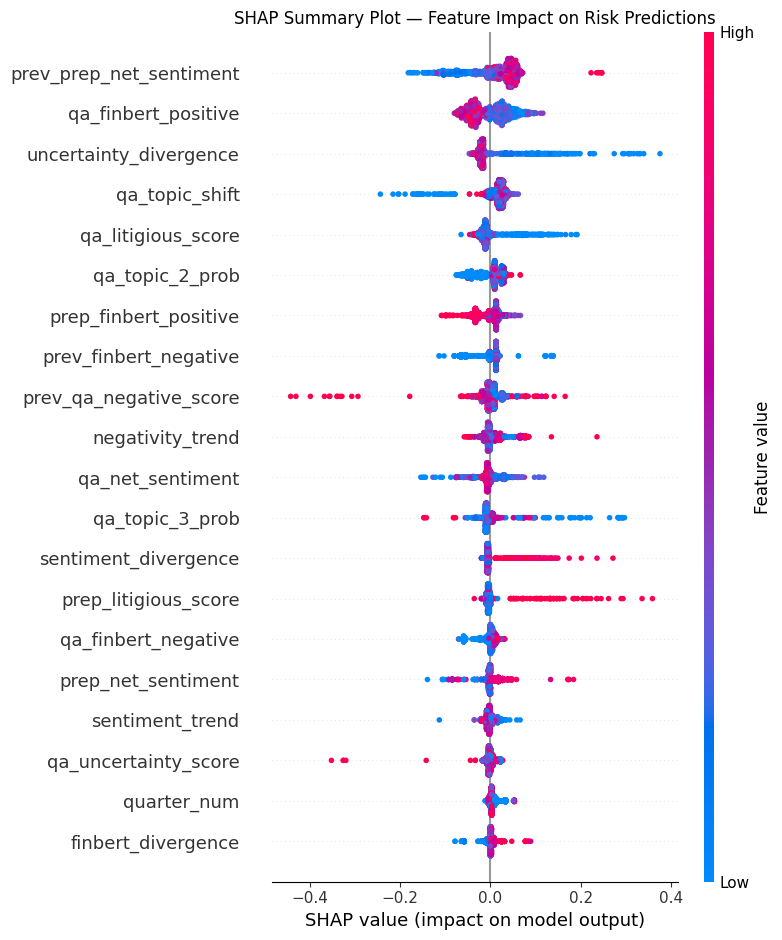


  INTERPRETING SHAP RESULTS
  Low magnitude SHAP values (x-axis near 0 for most features)
  → features lack strong directional signal to separate labels.
  Negative permutation importance → model fits noise on train set
  that does not generalise to test set.
  Healthy model: red dots (high feature value) push consistently
  in one direction; mixed red/blue = noisy or nonlinear relationship.


In [ ]:
# =============================================================================
# SHAP & Permutation Importance
# PySpark MLlib does not directly support SHAP, so this section fits a
# scikit-learn GBT approximation using the best Spark GBT parameters.
# =============================================================================

!pip install shap -q

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from pyspark.sql import SparkSession
from google.colab import drive

drive.mount('/content/drive')

print("\n" + "="*55)
print("  SHAP & PERMUTATION IMPORTANCE ANALYSIS")
print("="*55)

BASE_DIR   = "/content/drive/MyDrive/MIS_584_Project"
PARQUET_IN = f"{BASE_DIR}/Parquet/584_earnings_features"

spark       = SparkSession.builder.appName("584_ML_Models").config("spark.driver.maxResultSize", "0").getOrCreate()
df_spark    = spark.read.parquet(PARQUET_IN)
df_features = df_spark.toPandas()

# Match the scaled feature list from Step 7
FEATURE_COLS_SCALED = [
    'prep_net_sentiment_scaled',
    'prep_negative_score_scaled',
    'prep_uncertainty_score_scaled',
    'prep_litigious_score_scaled',
    'qa_net_sentiment_scaled',
    'qa_negative_score_scaled',
    'qa_uncertainty_score_scaled',
    'qa_litigious_score_scaled',
    'sentiment_divergence_scaled',
    'uncertainty_divergence_scaled',
    'tone_inconsistency_scaled',
    'qa_topic_shift_scaled',
    'qa_topic_2_prob_scaled',
    'qa_topic_3_prob_scaled',
    'quarter_num_scaled',
    'prep_finbert_positive_scaled',
    'prep_finbert_negative_scaled',
    'qa_finbert_positive_scaled',
    'qa_finbert_negative_scaled',
    'finbert_divergence_scaled',
    # sector excluded here — OHE not applied to sklearn/SHAP section;
    # sector is available as raw 'sector' column for groupby/descriptive analysis
    'prev_prep_net_sentiment_scaled',
    'prev_qa_negative_score_scaled',
    'prev_finbert_negative_scaled',
    'sentiment_trend_scaled',
    'negativity_trend_scaled',
]

df_features[FEATURE_COLS_SCALED] = df_features[FEATURE_COLS_SCALED].fillna(0.0)

# StringIndexer maps most-frequent label to 0.
# For SHAP we use a simple binary map — consistent within this sklearn model.
df_features['label'] = df_features['return_label'].map({'positive': 0, 'negative': 1})

all_years   = sorted(df_features['year'].unique().tolist())
TEST_YEARS  = [all_years[-1]]
TRAIN_YEARS = all_years[:-1]

train_pd = df_features[df_features['year'].isin(TRAIN_YEARS)]
test_pd  = df_features[df_features['year'].isin(TEST_YEARS)]

X_train = train_pd[FEATURE_COLS_SCALED].copy()
y_train = train_pd['label']
X_test  = test_pd[FEATURE_COLS_SCALED].copy()
y_test  = test_pd['label']

clean_feature_names       = [c.replace('_scaled', '') for c in FEATURE_COLS_SCALED]
X_train.columns           = clean_feature_names
X_test.columns            = clean_feature_names

# Approximate the tuned Spark GBT using the best parameters found above
print(f"Fitting sklearn GBT mirror "
      f"(max_depth={best_gbt.getMaxDepth()}, "
      f"n_estimators={best_gbt.getMaxIter()}, "
      f"learning_rate={best_gbt.getStepSize()})...")
sk_gbt = GradientBoostingClassifier(
    max_depth     = best_gbt.getMaxDepth(),
    n_estimators  = best_gbt.getMaxIter(),
    learning_rate = best_gbt.getStepSize(),
    random_state  = 42
)
sk_gbt.fit(X_train, y_train)

# ── Permutation Importance ─────────────────────────────────────────────────────
print("\nCalculating Permutation Importance...")
perm_importance = permutation_importance(
    sk_gbt, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':          clean_feature_names,
    'importance_mean':  perm_importance.importances_mean,
    'importance_std':   perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop Features by Permutation Importance (Impact on Accuracy):")
display(perm_df.head(10))

# ── SHAP Values ────────────────────────────────────────────────────────────────
print("\nCalculating SHAP values...")
explainer   = shap.TreeExplainer(sk_gbt)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
plt.title("SHAP Summary Plot — Feature Impact on Risk Predictions")
shap.summary_plot(shap_values, X_test, feature_names=clean_feature_names, show=False)
plt.tight_layout()
plt.show()

# Interpretation guide printed as output (not markdown in code):
print("\n" + "="*60)
print("  INTERPRETING SHAP RESULTS")
print("="*60)
print("  Low magnitude SHAP values (x-axis near 0 for most features)")
print("  → features lack strong directional signal to separate labels.")
print("  Negative permutation importance → model fits noise on train set")
print("  that does not generalise to test set.")
print("  Healthy model: red dots (high feature value) push consistently")
print("  in one direction; mixed red/blue = noisy or nonlinear relationship.")

In [ ]:
# =============================================================================
# Price Proxy Integration
# Add simple pre-earnings momentum and volatility features from yfinance, then
# test whether they improve the tuned GBT model.
# =============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR   = "/content/drive/MyDrive/MIS_584_Project"
PARQUET_IN = f"{BASE_DIR}/Parquet/584_earnings_features"

spark           = SparkSession.builder.appName("584_Financial_Integration").config("spark.driver.maxResultSize", "0").getOrCreate()
df_nlp_features = spark.read.parquet(PARQUET_IN)

# Same scaled language features used in the earlier GBT model
FEATURE_COLS_SCALED = [
    'prep_net_sentiment_scaled',
    'prep_negative_score_scaled',
    'prep_uncertainty_score_scaled',
    'prep_litigious_score_scaled',
    'qa_net_sentiment_scaled',
    'qa_negative_score_scaled',
    'qa_uncertainty_score_scaled',
    'qa_litigious_score_scaled',
    'sentiment_divergence_scaled',
    'uncertainty_divergence_scaled',
    'tone_inconsistency_scaled',
    'qa_topic_shift_scaled',
    'qa_topic_2_prob_scaled',
    'qa_topic_3_prob_scaled',
    'quarter_num_scaled',
    'prep_finbert_positive_scaled',
    'prep_finbert_negative_scaled',
    'qa_finbert_positive_scaled',
    'qa_finbert_negative_scaled',
    'finbert_divergence_scaled',
    'prev_prep_net_sentiment_scaled',
    'prev_qa_negative_score_scaled',
    'prev_finbert_negative_scaled',
    'sentiment_trend_scaled',
    'negativity_trend_scaled',
]

print("Fetching 30-day pre-earnings market proxies via yfinance...")
pdf_features = df_nlp_features.select('ticker', 'earnings_date').toPandas()
records      = []

for _, row in pdf_features.drop_duplicates().iterrows():
    ticker    = row['ticker']
    edate_str = row['earnings_date']

    try:
        edate      = datetime.strptime(edate_str, '%Y-%m-%d')
        start_date = edate - timedelta(days=45)

        hist = yf.Ticker(ticker).history(
            start=start_date.strftime('%Y-%m-%d'), end=edate_str
        )

        if len(hist) > 5:
            hist_return    = (hist['Close'].iloc[-1] - hist['Close'].iloc[0]) / hist['Close'].iloc[0]
            daily_returns  = hist['Close'].pct_change().dropna()
            hist_volatility = daily_returns.std()

            records.append({
                'ticker':             ticker,
                'earnings_date':      edate_str,
                'pre_momentum_30d':   float(hist_return),
                'pre_volatility_30d': float(hist_volatility)
            })
        else:
            records.append({
                'ticker':             ticker,
                'earnings_date':      edate_str,
                'pre_momentum_30d':   0.0,
                'pre_volatility_30d': 0.0
            })
    except Exception:
        records.append({
            'ticker':             ticker,
            'earnings_date':      edate_str,
            'pre_momentum_30d':   0.0,
            'pre_volatility_30d': 0.0
        })

    time.sleep(0.1)

df_proxies_pd    = pd.DataFrame(records)
df_proxies_spark = spark.createDataFrame(df_proxies_pd)
print(f"\nSuccessfully extracted proxies for {len(df_proxies_pd)} earning events.")
display(df_proxies_pd.head())

# ── Join and scale proxies ────────────────────────────────────────────────────
df_final_combined = df_nlp_features.join(
    df_proxies_spark, on=['ticker', 'earnings_date'], how='inner'
)

# ── Temporal split for price proxy models ─────────────────────────────────────
all_years_proxy = sorted([
    r['year'] for r in df_final_combined.select('year').distinct().collect()
])

TEST_YEARS_P  = [all_years_proxy[-1]]
TRAIN_YEARS_P = all_years_proxy[:-1]

train_proxies = df_final_combined.filter(F.col('year').isin(TRAIN_YEARS_P))

# Assemble momentum + volatility into a single vector for scaling
proxy_assembler = VectorAssembler(
    inputCols=['pre_momentum_30d', 'pre_volatility_30d'],
    outputCol='raw_proxies'
)
df_final_combined = proxy_assembler.transform(df_final_combined)
train_proxies     = proxy_assembler.transform(train_proxies)

proxy_scaler  = MinMaxScaler(inputCol='raw_proxies', outputCol='scaled_proxies')
scaler_model  = proxy_scaler.fit(train_proxies)           # fit on train only
df_final_combined = scaler_model.transform(df_final_combined)

# Convert the scaled proxy vector into separate scalar columns for VectorAssembler
df_final_combined = (
    df_final_combined
    .withColumn('pre_momentum_scaled',
                vector_to_array(F.col('scaled_proxies')).getItem(0))
    .withColumn('pre_volatility_scaled',
                vector_to_array(F.col('scaled_proxies')).getItem(1))
)

# Final feature vector: language features plus the two market proxy features
FINAL_FEATURES = FEATURE_COLS_SCALED + ['pre_momentum_scaled', 'pre_volatility_scaled']

# Fill NaN before assembling
df_final_combined = df_final_combined.fillna(0.0, subset=FINAL_FEATURES)

final_assembler   = VectorAssembler(
    inputCols=FINAL_FEATURES, outputCol='final_features_vector'
)
df_final_combined = final_assembler.transform(df_final_combined)

# ── Label and split ────────────────────────────────────────────────────────────
from pyspark.ml.feature import StringIndexer

indexer_proxy = StringIndexer(
    inputCol='return_label', outputCol='label', handleInvalid='skip'
)
df_final_ready = indexer_proxy.fit(df_final_combined).transform(df_final_combined)

train_final = df_final_ready.filter(F.col('year').isin(TRAIN_YEARS_P))
test_final  = df_final_ready.filter(F.col('year').isin(TEST_YEARS_P))

# ── Train final GBT ────────────────────────────────────────────────────────────
print(f"\nTraining Final GBT Model... "
      f"(Train: {train_final.count()}, Test: {test_final.count()})")

final_gbt = GBTClassifier(
    featuresCol='final_features_vector',
    labelCol='label',
    maxDepth=3,
    maxIter=20,
    seed=42
)
final_gbt_model = final_gbt.fit(train_final)

evaluator_final = BinaryClassificationEvaluator(
    labelCol='label', rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)

final_predictions = final_gbt_model.transform(test_final)
final_auc         = evaluator_final.evaluate(final_predictions)

print(f"\n{'='*50}")
print(f"  FINAL GBT AUC (NLP + Real Market Proxies): {final_auc:.4f}")
print(f"{'='*50}")
base_auc_s8 = gbt_results['auc'] if 'gbt_results' in dir() and gbt_results['auc'] is not None else None
if base_auc_s8 is not None:
    delta_proxy = final_auc - base_auc_s8
    print(f"  Baseline GBT AUC (NLP only):               {base_auc_s8:.4f}")
    print(f"  Improvement from adding market proxies:    {delta_proxy:+.4f}")
else:
    print("  (Run Step 8 in the same session to see NLP-only baseline comparison)")

spark.stop()
print("Spark session stopped.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fetching 30-day pre-earnings market proxies via yfinance...

Successfully extracted proxies for 6924 earning events.


,ticker,earnings_date,pre_momentum_30d,pre_volatility_30d
0,A,2021-05-25,0.015769,0.010961
1,A,2021-08-17,0.087864,0.006854
2,A,2021-11-22,0.077589,0.011544
3,A,2022-02-22,-0.090314,0.018764
4,A,2022-08-16,0.110650,0.021425



Training Final GBT Model... (Train: 5208, Test: 1716)

  FINAL GBT AUC (NLP + Real Market Proxies): 0.4773
  (Run Step 8 in the same session to see NLP-only baseline comparison)
Spark session stopped.
